In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, StatePreparation
from qiskit.quantum_info import Statevector

# 1. 경로 설정 (notebooks 폴더에서 상위 폴더인 루트를 path에 추가)
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# 2. src 모듈 임포트
from src.ansatz import create_qaoa_ansatz
from src.problem_setup import (
    get_b_statevector,
    create_b_vector_gaussian,
    create_b_vector_sine,
    create_b_vector_uniform,
    create_b_vector_random,
    create_b_vector_linear
)
from src.decomposition import decompose_A_matrix, dict_to_operator
from src.solvers.exact import run_vqe_for_poisson as run_exact
from src.solvers.hybrid import run_vqe_hybrid_v2 as run_hybrid
from src.solvers.hardware import run_vqe_fully_hardware_v2 as run_hardware

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


In [2]:
def get_classical_solution(m: int, b_creation_func) -> np.ndarray:
    """고전적 정답(Exact Solution) 계산"""
    n = 2**m
    A_op = dict_to_operator(decompose_A_matrix(m), m)
    grid = np.linspace(0, 1, n + 2)[1:-1]
    
    # b 함수 처리
    if "gaussian" in b_creation_func.__name__:
        b_vec = np.exp(-(grid - 0.5)**2 / (2 * 0.2**2))
    elif "sine" in b_creation_func.__name__:
        b_vec = np.sin(2 * np.pi * grid)
    elif "uniform" in b_creation_func.__name__:
        b_vec = np.ones(n)
    elif "linear" in b_creation_func.__name__:
        b_vec = grid
    else:
        b_vec = b_creation_func(n)

    try:
        x_exact = la.solve(A_op.data, b_vec)
    except:
        x_exact = la.pinv(A_op.data) @ b_vec
        
    norm = np.linalg.norm(x_exact)
    return x_exact / norm if norm > 0 else x_exact

def align_phase(target_vec, ref_vec):
    """위상 정렬 (시각화 보정용)"""
    overlap = np.dot(ref_vec.conj(), target_vec)
    if np.abs(overlap) < 1e-10: return target_vec
    return target_vec / (overlap / np.abs(overlap))

def plot_results(m, x_exact, x_vqe, fidelity, title_suffix):
    """결과 그래프 출력"""
    n = 2**m
    grid = np.linspace(0, 1, n + 2)[1:-1]
    x_vqe_aligned = align_phase(x_vqe, x_exact)
    
    plt.figure(figsize=(10, 6))
    plt.plot(grid, x_exact.real, 'k-', linewidth=2, label='Exact Solution')
    plt.plot(grid, x_vqe_aligned.real, 'ro--', alpha=0.8, label=f'VQE (F={fidelity:.4f})')
    plt.title(f"Poisson Solver Result\n{title_suffix}")
    plt.legend(); plt.grid(True, linestyle=':')
    plt.show()

In [5]:
# === [설정] 실험 조건 ===
M_QUBITS = 3              # 큐비트 수
LAYERS = 3                # Ansatz 레이어 수
B_FUNC = create_b_vector_gaussian  # b 벡터 종류 (gaussian, sine, uniform...)
ANSATZ_TYPE = 'QAOA'     # 'RealAmplitudes' or 'QAOA'

# 실행 모드: 'exact', 'hybrid', 'hardware'
SOLVER_MODE = 'hardware' 

# 최적화 설정
OPTIMIZER = 'COBYLA'
BACKEND_MODE = 'noiseless' # 'noiseless', 'noisy_sim', 'real', 'gpu'
OPTIONS = {'maxiter': 2000, 'tol': 1e-4}

print(f"🚀 설정 완료: {M_QUBITS}Q, {SOLVER_MODE}, {BACKEND_MODE}")

🚀 설정 완료: 3Q, hardware, noiseless


[1] Initializing Problem...
[2] Running VQE (hardware mode)...
[INFO] Setting up backend for mode: noiseless
[INFO] Generating and transpiling Hadamard test circuits...

[INFO] Starting VQE Optimization (COBYLA, Backend: noiseless)...
Iter 70: Cost=0.081288 (<A^2>=0.1017, Overlap=0.0204)
Final Cost: 0.027138
Final Fidelity: 0.974294


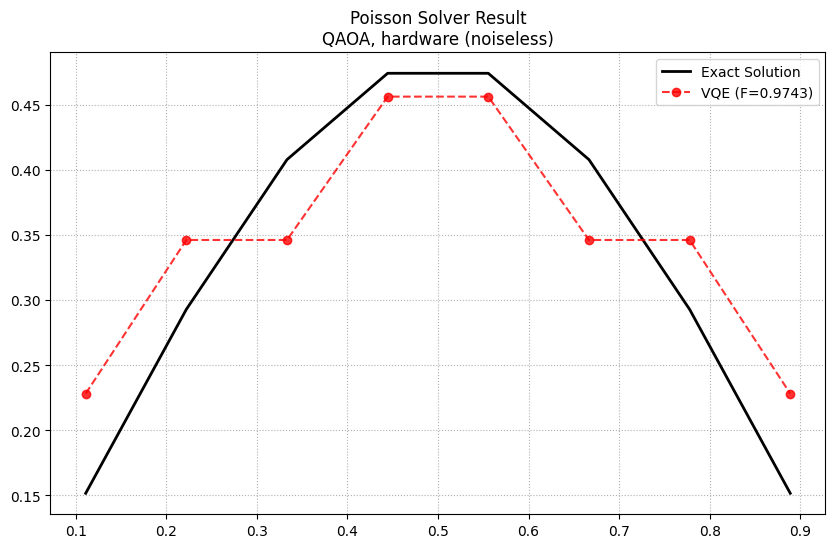

In [6]:
# 1. 문제 및 Ansatz 준비
print("[1] Initializing Problem...")
b_vec, b_data = get_b_statevector(M_QUBITS, B_FUNC)

if ANSATZ_TYPE == 'QAOA':
    ansatz = create_qaoa_ansatz(M_QUBITS, layers=LAYERS)
else:
    ansatz = RealAmplitudes(M_QUBITS, entanglement='linear', reps=LAYERS)

# 2. VQE 실행
result = None
print(f"[2] Running VQE ({SOLVER_MODE} mode)...")

if SOLVER_MODE == 'hybrid':
    # Hybrid Solver (EstimatorV2)
    result = run_hybrid(
        M_QUBITS, ansatz, b_vec, 
        backend_mode=BACKEND_MODE,
        optimizer=OPTIMIZER, options=OPTIONS
    )
elif SOLVER_MODE == 'hardware':
    # Hardware Solver (SamplerV2) -> Circuit 형태의 b 필요
    b_circuit = QuantumCircuit(M_QUBITS)
    b_circuit.append(StatePreparation(b_data), range(M_QUBITS))
    
    result = run_hardware(
        M_QUBITS, ansatz, b_circuit, 
        backend_mode=BACKEND_MODE,
        optimizer=OPTIMIZER, options=OPTIONS
    )
else:
    # Exact Solver
    res_tuple = run_exact(
        M_QUBITS, ansatz, b_creation_func=B_FUNC,
        optimizer=OPTIMIZER, options=OPTIONS
    )
    result = res_tuple[0] if isinstance(res_tuple, tuple) else res_tuple

# 3. 결과 정리
print("\n" + "="*40)
print(f"Final Cost: {result.fun:.6f}")

# 상태 벡터 재구성
opt_params = result.x
final_state = Statevector(ansatz.assign_parameters(opt_params))

# 고전적 해 및 Fidelity 계산
exact_sol = get_classical_solution(M_QUBITS, B_FUNC)
fidelity = np.abs(final_state.inner(Statevector(exact_sol)))**2

print(f"Final Fidelity: {fidelity:.6f}")
print("="*40)

# 4. 시각화
plot_results(M_QUBITS, exact_sol, final_state.data, fidelity, 
             title_suffix=f"{ANSATZ_TYPE}, {SOLVER_MODE} ({BACKEND_MODE})")